# Tutorial 4.2: PV and probabilistic forecasting

This tutorial extends the day-ahead forecasting workflow from Tutorial 4.1. We first use the GEFCom2012 aggregate load to study forecast uncertainty, because its data and point-forecast specification are already familiar. We then apply the same principles to normalised PV output and day-ahead ECMWF weather forecasts from the GEFCom2014 solar track.

The main distinction is between:

- a **point forecast**, which provides one value at each forecast horizon;
- a **prediction interval**, which provides marginal lower and upper bounds; and
- a **scenario forecast**, which provides complete trajectories and preserves relationships between hours.

## Learning outcomes

By the end of the tutorial, you should be able to:

1. construct constant and hour-dependent residual prediction intervals;
2. fit linear quantile-regression models;
3. assess coverage, sharpness, quantile score and interval score;
4. generate independent and temporally correlated Gaussian scenarios; and
5. apply physical constraints to PV point forecasts and prediction intervals.

## Indicative schedule

- set-up, point forecast and residual diagnosis: 10 minutes;
- residual-based intervals: 15 minutes;
- quantile regression and interval evaluation: 15 minutes;
- Gaussian trajectory scenarios: 15 minutes;
- PV point forecasting and bad practices: 25 minutes;
- PV intervals, quantiles and scenarios: 20 minutes;
- discussion: 5 minutes.


## 1. Set-up and GEFCom2012 data

We reuse the aggregate `Z21` load and mean temperature extract from Tutorial 4.1. The source is GEFCom2012, documented in `data/tutorial_4_1/README.md`.

The GEFCom `Temperature_history` file contains historical weather forecasts belonging to the training dataset. Each weather forecast is indexed by its valid timestamp and is aligned with the load observation at that timestamp. Unlike Tutorial 4.1, which used a common previous-day proxy for both datasets, this tutorial uses the supplied target-hour weather forecast directly.

The load forecast is issued at the end of each day for all 24 hours of the next day. The code evaluates many such day-ahead forecasts together in chronological tables. We treat the supplied target-hour weather forecast as available at the corresponding day-ahead origin.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, QuantileRegressor, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA_PATH = Path("data") / "tutorial_4_1" / "gefcom2012_system_load.csv"

system_data = pd.read_csv(
    DATA_PATH,
    index_col="timestamp",
    parse_dates=True,
).sort_index()

expected_index = pd.date_range(
    system_data.index.min(), system_data.index.max(), freq="h"
)

print("Rows:", len(system_data))
print("Period:", system_data.index.min(), "to", system_data.index.max())
print("Duplicate timestamps:", system_data.index.duplicated().sum())
print("Missing timestamps:", len(expected_index.difference(system_data.index)))
print("Missing values by column:")
display(system_data.isna().sum().to_frame("Count"))

Rows: 8760
Period: 2007-01-01 00:00:00 to 2007-12-31 23:00:00
Duplicate timestamps: 0
Missing timestamps: 0
Missing values by column:


,Count
load_mw,0
air_temperature_c,0


## 2. Point forecast and chronological split

We use the same transparent predictors as Tutorial 4.1:

- load from the same hour on the previous day and previous week;
- the supplied target-hour weather forecast, which has the same valid-time index as the load; and
- calendar variables known at the forecast origin.

The feature `temperature_forecast_c` is therefore contemporaneous in valid time but not in information time: it describes target-hour weather and is assumed to have been issued before the day-ahead load forecast.

The split follows the lecture terminology:

- **training:** fit the point and quantile models;
- **calibration:** estimate residual uncertainty; and
- **test:** evaluate every method once.

The calibration set must not be used to report final performance. The test set must not influence model fitting, interval construction or parameter selection.

In [2]:
def make_features(data):
    features = pd.DataFrame(index=data.index)
    features["target"] = data["load_mw"]
    features["load_lag_24"] = data["load_mw"].shift(24)
    features["load_lag_168"] = data["load_mw"].shift(168)
    features["temperature_forecast_c"] = data["air_temperature_c"]

    hour = features.index.hour
    day_of_week = features.index.dayofweek
    features["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    features["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    features["day_sin"] = np.sin(2 * np.pi * day_of_week / 7)
    features["day_cos"] = np.cos(2 * np.pi * day_of_week / 7)
    features["is_weekend"] = (day_of_week >= 5).astype(int)
    return features.dropna()


FEATURE_COLUMNS = [
    "load_lag_24",
    "load_lag_168",
    "temperature_forecast_c",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "is_weekend",
]

features = make_features(system_data)

TRAIN_START = pd.Timestamp("2007-01-08 00:00")
TRAIN_END = pd.Timestamp("2007-06-30 23:00")
CALIBRATION_START = pd.Timestamp("2007-07-01 00:00")
CALIBRATION_END = pd.Timestamp("2007-07-31 23:00")
TEST_START = pd.Timestamp("2007-08-01 00:00")
TEST_END = pd.Timestamp("2007-08-28 23:00")

train = features.loc[TRAIN_START:TRAIN_END]
calibration = features.loc[CALIBRATION_START:CALIBRATION_END]
test = features.loc[TEST_START:TEST_END]

assert len(calibration) == 31 * 24
assert len(test) == 28 * 24
assert not train.isna().any().any()
assert not calibration.isna().any().any()
assert not test.isna().any().any()

pd.DataFrame({
    "Start": [train.index.min(), calibration.index.min(), test.index.min()],
    "End": [train.index.max(), calibration.index.max(), test.index.max()],
    "Hours": [len(train), len(calibration), len(test)],
}, index=["Training", "Calibration", "Test"])

,Start,End,Hours
Training,2007-01-08,2007-06-30 23:00:00,4176
Calibration,2007-07-01,2007-07-31 23:00:00,744
Test,2007-08-01,2007-08-28 23:00:00,672


### 2.1 Worked point-forecast baseline

The pooled Ridge model is supplied so that tutorial time can focus on uncertainty. The calibration residual is

$$
e_t = y_t - \hat{y}_t.
$$

A positive residual means the point forecast was too low. The residual plot by hour motivates interval widths that can change through the day.

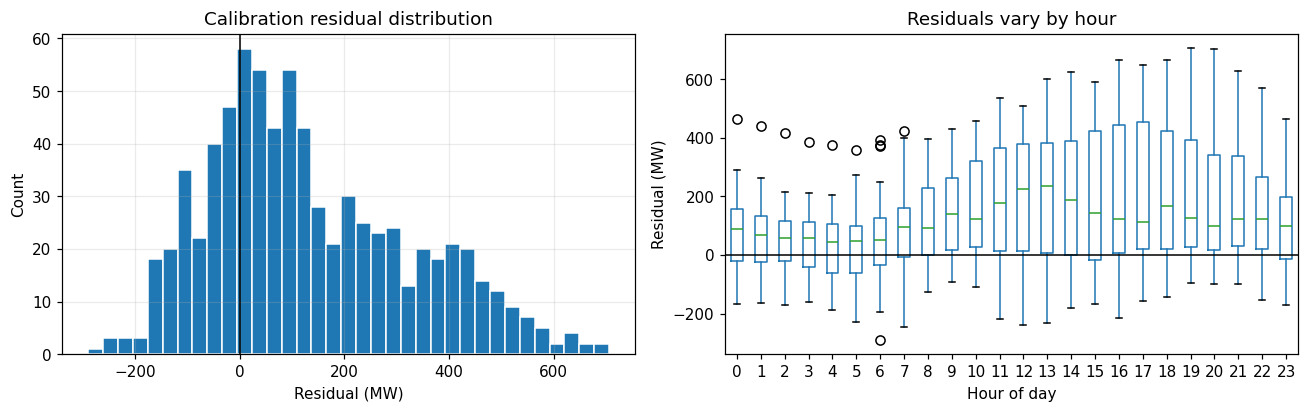

In [3]:
point_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10.0),
)
point_model.fit(train[FEATURE_COLUMNS], train["target"])

calibration_point = pd.Series(
    point_model.predict(calibration[FEATURE_COLUMNS]),
    index=calibration.index,
    name="Point forecast",
)
test_point = pd.Series(
    point_model.predict(test[FEATURE_COLUMNS]),
    index=test.index,
    name="Point forecast",
)

calibration_residuals = calibration["target"] - calibration_point

residual_frame = pd.DataFrame({
    "Residual (MW)": calibration_residuals,
    "Hour of day": calibration_residuals.index.hour,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(calibration_residuals, bins=35, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set(title="Calibration residual distribution", xlabel="Residual (MW)", ylabel="Count")

residual_frame.boxplot(
    column="Residual (MW)", by="Hour of day", ax=axes[1], grid=False
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="Residuals vary by hour", xlabel="Hour of day", ylabel="Residual (MW)")
fig.suptitle("")
plt.tight_layout()
plt.show()

## 3. Task 1 — Residual-based prediction intervals

For a central 90% interval, set $\alpha=0.10$ and estimate the 5th and 95th percentiles of calibration residuals.

The first method pools all calibration residuals. It adds the same two residual quantiles to every point forecast, so its width remains constant throughout the day.

The second method estimates separate residual quantiles for each hour of day. It can represent systematic changes in uncertainty between, for example, the morning ramp and the overnight period. Each hourly estimate uses fewer calibration observations, so the estimates can also be noisier.

In [4]:
def constant_residual_interval(point_forecast, residuals, alpha=0.10):
    lower_offset, upper_offset = np.quantile(
        residuals.to_numpy(), [alpha / 2, 1 - alpha / 2]
    )
    lower = point_forecast + lower_offset
    upper = point_forecast + upper_offset
    return lower.rename("Lower"), upper.rename("Upper")


def hourly_residual_interval(point_forecast, residuals, alpha=0.10):
    calibration_frame = pd.DataFrame({
        "residual": residuals,
        "hour": residuals.index.hour,
    })
    hourly_quantiles = calibration_frame.groupby("hour")["residual"].quantile(
        [alpha / 2, 1 - alpha / 2]
    ).unstack()

    forecast_hours = point_forecast.index.hour
    lower_offsets = hourly_quantiles.loc[forecast_hours, alpha / 2].to_numpy()
    upper_offsets = hourly_quantiles.loc[forecast_hours, 1 - alpha / 2].to_numpy()

    lower = pd.Series(
        point_forecast.to_numpy() + lower_offsets,
        index=point_forecast.index,
        name="Lower",
    )
    upper = pd.Series(
        point_forecast.to_numpy() + upper_offsets,
        index=point_forecast.index,
        name="Upper",
    )
    return lower, upper


NOMINAL_COVERAGE = 0.90
ALPHA = 1 - NOMINAL_COVERAGE

constant_lower, constant_upper = constant_residual_interval(
    test_point, calibration_residuals, alpha=ALPHA
)
hourly_lower, hourly_upper = hourly_residual_interval(
    test_point, calibration_residuals, alpha=ALPHA
)

intervals = {
    "Constant residual": (constant_lower, constant_upper),
    "Hourly residual": (hourly_lower, hourly_upper),
}

## 4. Task 2 — Interval and quantile metrics

For observations $y_t$, lower bounds $L_t$ and upper bounds $U_t$:

$$
\text{Coverage} = \frac{100}{n}\sum_t \mathbb{1}\{L_t \le y_t \le U_t\},
\qquad
\text{Mean width} = \frac{1}{n}\sum_t (U_t-L_t).
$$

Coverage measures calibration and width measures sharpness. Widths should only be compared for the same nominal coverage.

The quantile score at level $q$ is the mean pinball loss:

$$
QS_q = \frac{1}{n}\sum_t \max\{q(y_t-\hat{y}_{q,t}),\;(q-1)(y_t-\hat{y}_{q,t})\}.
$$

The interval score combines width with penalties for observations outside a central interval. Lower values are better for both quantile and interval scores.

In [5]:
def _equal_arrays(*values):
    arrays = [np.asarray(value, dtype=float) for value in values]
    lengths = {len(array) for array in arrays}
    if len(lengths) != 1:
        raise ValueError("All inputs must have identical lengths.")
    if any(not np.isfinite(array).all() for array in arrays):
        raise ValueError("Inputs must contain only finite values.")
    return arrays


def empirical_coverage(actual, lower, upper):
    actual_array, lower_array, upper_array = _equal_arrays(actual, lower, upper)
    if np.any(lower_array > upper_array):
        raise ValueError("Lower bounds must not exceed upper bounds.")
    covered = (actual_array >= lower_array) & (actual_array <= upper_array)
    return 100 * covered.mean()


def mean_interval_width(lower, upper):
    lower_array, upper_array = _equal_arrays(lower, upper)
    if np.any(lower_array > upper_array):
        raise ValueError("Lower bounds must not exceed upper bounds.")
    return np.mean(upper_array - lower_array)


def quantile_score(actual, quantile_forecast, quantile):
    if not 0 < quantile < 1:
        raise ValueError("quantile must lie strictly between zero and one.")
    actual_array, forecast_array = _equal_arrays(actual, quantile_forecast)
    error = actual_array - forecast_array
    return np.mean(np.maximum(quantile * error, (quantile - 1) * error))


def interval_score(actual, lower, upper, alpha=0.10):
    if not 0 < alpha < 1:
        raise ValueError("alpha must lie strictly between zero and one.")
    actual_array, lower_array, upper_array = _equal_arrays(actual, lower, upper)
    if np.any(lower_array > upper_array):
        raise ValueError("Lower bounds must not exceed upper bounds.")

    score = upper_array - lower_array
    score += (2 / alpha) * (lower_array - actual_array) * (actual_array < lower_array)
    score += (2 / alpha) * (actual_array - upper_array) * (actual_array > upper_array)
    return np.mean(score)

In [6]:
def summarise_intervals(actual, interval_dictionary, alpha=0.10):
    rows = {}
    for method_name, (lower, upper) in interval_dictionary.items():
        rows[method_name] = {
            "Coverage (%)": empirical_coverage(actual, lower, upper),
            "Mean width (MW)": mean_interval_width(lower, upper),
            "Interval score": interval_score(actual, lower, upper, alpha),
        }
    return pd.DataFrame(rows).T


residual_interval_summary = summarise_intervals(
    test["target"], intervals, alpha=ALPHA
)
residual_interval_summary.round(2)

,Coverage (%),Mean width (MW),Interval score
Constant residual,81.25,624.17,1034.83
Hourly residual,74.26,515.88,1054.54


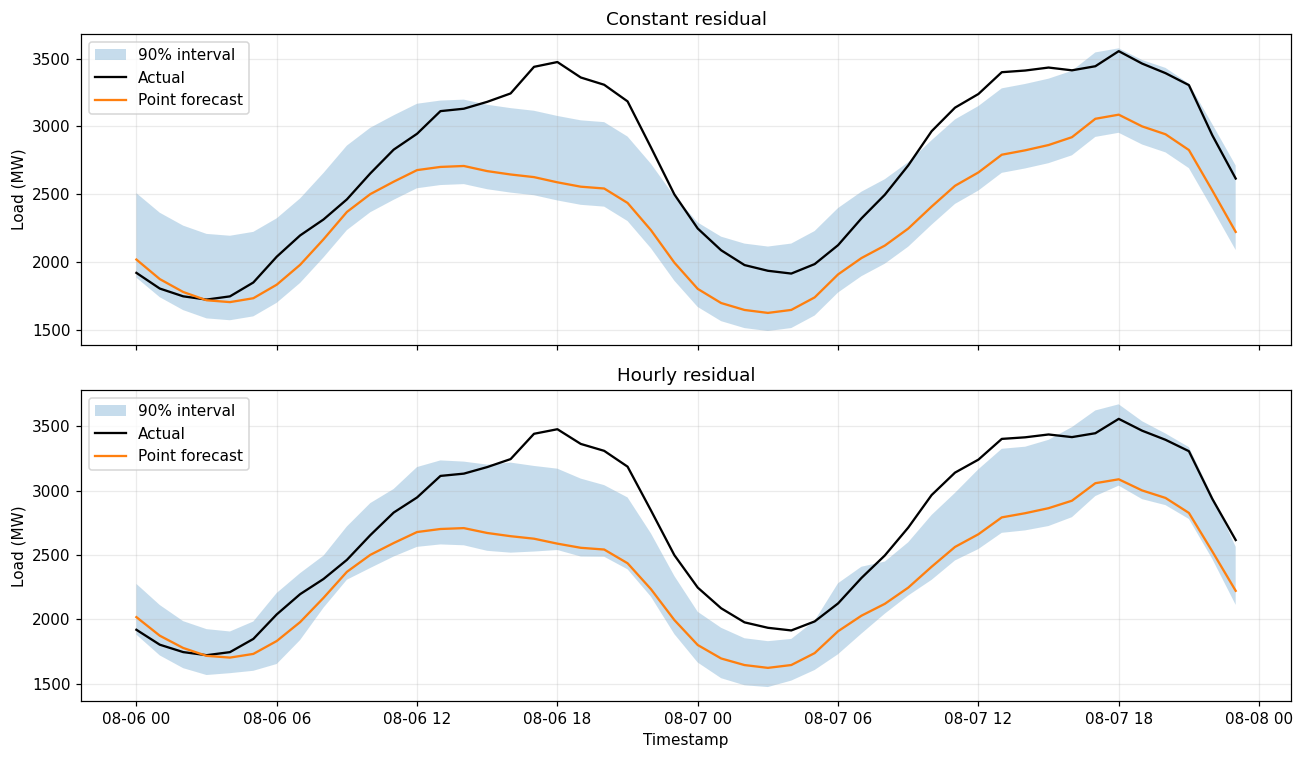

In [7]:
plot_index = test.loc["2007-08-06":"2007-08-07"].index

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, (method_name, (lower, upper)) in zip(axes, intervals.items()):
    ax.fill_between(
        plot_index,
        lower.loc[plot_index].to_numpy(),
        upper.loc[plot_index].to_numpy(),
        alpha=0.25,
        label="90% interval",
    )
    ax.plot(plot_index, test.loc[plot_index, "target"], color="black", label="Actual")
    ax.plot(plot_index, test_point.loc[plot_index], color="tab:orange", label="Point forecast")
    ax.set(title=method_name, ylabel="Load (MW)")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## 5. Task 3 — Linear quantile regression

Residual intervals shift one point forecast using errors observed on the calibration set. Quantile regression instead estimates a conditional quantile directly. We fit separate linear models for

$$
q \in \{0.05, 0.10, 0.15, 0.25, 0.50, 0.75, 0.85, 0.90, 0.95\}
$$

using pinball loss. These quantiles define central 50%, 70%, 80% and 90% prediction intervals. The additional intervals let us assess whether empirical coverage tracks nominal coverage across several probability levels, rather than judging calibration from one 90% interval alone.

The models use the training period only. The calibration period remains reserved for the residual methods, which keeps the comparison transparent. Separately fitted quantiles can cross; the code counts any adjacent crossings and sorts the forecasts at each timestamp before constructing intervals.


In [8]:
QUANTILES = [
    0.05, 0.10, 0.15, 0.25, 0.50, 0.75, 0.85, 0.90, 0.95
]
quantile_models = {}
raw_quantile_predictions = pd.DataFrame(index=test.index)

for quantile in QUANTILES:
    model = make_pipeline(
        StandardScaler(),
        QuantileRegressor(quantile=quantile, alpha=0.01, solver="highs"),
    )
    model.fit(train[FEATURE_COLUMNS], train["target"])
    quantile_models[quantile] = model
    raw_quantile_predictions[quantile] = model.predict(test[FEATURE_COLUMNS])

crossing_mask = (
    raw_quantile_predictions.diff(axis=1).iloc[:, 1:].lt(0).any(axis=1)
)
print("Timestamps with crossing quantiles:", crossing_mask.sum())

# Sorting each row gives non-decreasing reported quantiles. This simple repair
# is transparent, although joint/non-crossing quantile models are preferable
# in applications where the complete distribution is the main output.
ordered_predictions = np.sort(raw_quantile_predictions.to_numpy(), axis=1)
quantile_predictions = pd.DataFrame(
    ordered_predictions,
    index=test.index,
    columns=QUANTILES,
)

intervals["Linear quantile regression"] = (
    quantile_predictions[0.05].rename("Lower"),
    quantile_predictions[0.95].rename("Upper"),
)


Timestamps with crossing quantiles: 99


### 5.1 Coverage-calibration curve

A coverage-calibration curve is analogous to a reliability diagram for prediction intervals. Each point compares a central interval's nominal coverage with the proportion of test observations that actually fall between its bounds.

- A point on the diagonal is calibrated at that coverage level.
- A point below the diagonal indicates **undercoverage**: the interval covers fewer observations than promised and may be too narrow or biased.
- A point above the diagonal indicates **overcoverage**: the interval covers more observations than promised and may be unnecessarily wide.

This is not a classical Q–Q plot of two distributions, but its diagonal interpretation is similar and is often more direct for explaining interval calibration.

The plot also includes two deliberately exaggerated **synthetic** points so that undercoverage and overcoverage remain visually obvious on a lecture slide. Cross markers identify these teaching examples; circular markers are the results calculated from GEFCom2012.


,Nominal coverage (%),Empirical coverage (%),Coverage gap (percentage points)
Interval,,,
50% interval,50.0,51.2,1.2
70% interval,70.0,70.4,0.4
80% interval,80.0,80.5,0.5
90% interval,90.0,89.1,-0.9


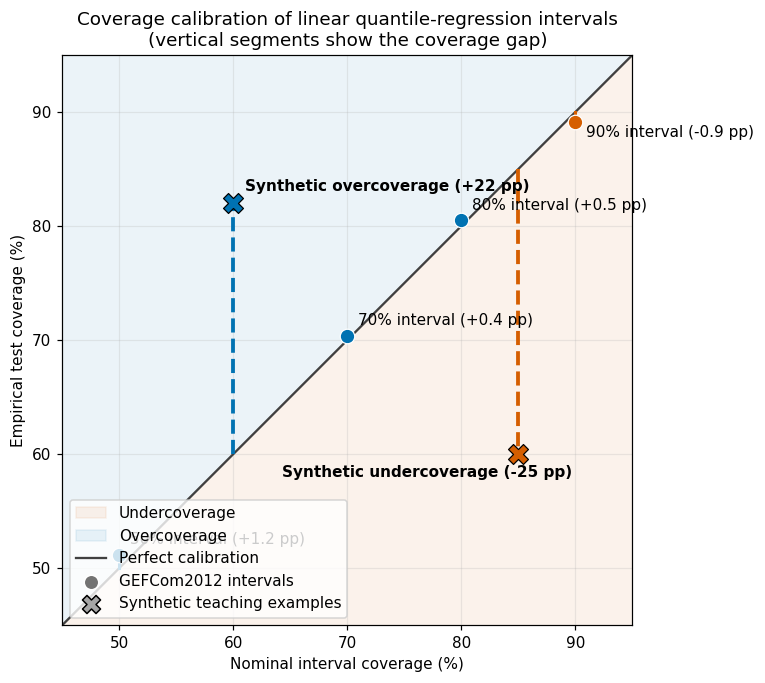

In [9]:
CENTRAL_INTERVAL_QUANTILES = {
    "50% interval": (0.25, 0.75),
    "70% interval": (0.15, 0.85),
    "80% interval": (0.10, 0.90),
    "90% interval": (0.05, 0.95),
}

coverage_rows = []
for interval_name, (lower_quantile, upper_quantile) in CENTRAL_INTERVAL_QUANTILES.items():
    nominal_coverage = 100 * (upper_quantile - lower_quantile)
    observed_coverage = empirical_coverage(
        test["target"],
        quantile_predictions[lower_quantile],
        quantile_predictions[upper_quantile],
    )
    coverage_rows.append({
        "Interval": interval_name,
        "Nominal coverage (%)": nominal_coverage,
        "Empirical coverage (%)": observed_coverage,
        "Coverage gap (percentage points)": observed_coverage - nominal_coverage,
    })

coverage_calibration = pd.DataFrame(coverage_rows).set_index("Interval")
display(coverage_calibration.round(1))

# Deliberately exaggerated teaching examples. These are not model results.
synthetic_coverage_examples = pd.DataFrame(
    {
        "Nominal coverage (%)": [60.0, 85.0],
        "Empirical coverage (%)": [82.0, 60.0],
    },
    index=["Synthetic overcoverage", "Synthetic undercoverage"],
)
synthetic_coverage_examples["Coverage gap (percentage points)"] = (
    synthetic_coverage_examples["Empirical coverage (%)"]
    - synthetic_coverage_examples["Nominal coverage (%)"]
)

fig, ax = plt.subplots(figsize=(7, 7))
diagonal = np.linspace(0, 100, 201)
ax.fill_between(
    diagonal, 0, diagonal,
    color="#D55E00", alpha=0.08, label="Undercoverage",
)
ax.fill_between(
    diagonal, diagonal, 100,
    color="#0072B2", alpha=0.08, label="Overcoverage",
)
ax.plot(diagonal, diagonal, color="0.25", linewidth=1.5, label="Perfect calibration")

for interval_name, row in coverage_calibration.iterrows():
    gap = row["Coverage gap (percentage points)"]
    point_colour = "#D55E00" if gap < 0 else "#0072B2"
    ax.plot(
        [row["Nominal coverage (%)"], row["Nominal coverage (%)"]],
        [row["Nominal coverage (%)"], row["Empirical coverage (%)"]],
        color=point_colour,
        linewidth=2,
        zorder=2,
    )
    ax.scatter(
        row["Nominal coverage (%)"],
        row["Empirical coverage (%)"],
        s=90,
        color=point_colour,
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )
    ax.annotate(
        f"{interval_name} ({gap:+.1f} pp)",
        (row["Nominal coverage (%)"], row["Empirical coverage (%)"]),
        xytext=(7, -10 if gap < 0 else 7),
        textcoords="offset points",
    )

for example_name, row in synthetic_coverage_examples.iterrows():
    gap = row["Coverage gap (percentage points)"]
    point_colour = "#0072B2" if gap > 0 else "#D55E00"
    ax.plot(
        [row["Nominal coverage (%)"], row["Nominal coverage (%)"]],
        [row["Nominal coverage (%)"], row["Empirical coverage (%)"]],
        color=point_colour,
        linewidth=2.5,
        linestyle="--",
        zorder=2,
    )
    ax.scatter(
        row["Nominal coverage (%)"],
        row["Empirical coverage (%)"],
        s=170,
        marker="X",
        color=point_colour,
        edgecolor="black",
        linewidth=0.8,
        zorder=4,
    )
    label_offset = (8, 8) if gap > 0 else (-155, -15)
    ax.annotate(
        f"{example_name} ({gap:+.0f} pp)",
        (row["Nominal coverage (%)"], row["Empirical coverage (%)"]),
        xytext=label_offset,
        textcoords="offset points",
        fontweight="bold",
    )

# Empty artists provide an unambiguous marker key without duplicating labels.
ax.scatter(
    [], [], s=90, marker="o", color="0.45", edgecolor="white",
    label="GEFCom2012 intervals",
)
ax.scatter(
    [], [], s=140, marker="X", color="0.65", edgecolor="black",
    label="Synthetic teaching examples",
)

ax.set(
    xlim=(45, 95),
    ylim=(45, 95),
    aspect="equal",
    xlabel="Nominal interval coverage (%)",
    ylabel="Empirical test coverage (%)",
    title="Coverage calibration of linear quantile-regression intervals\n"
          "(vertical segments show the coverage gap)",
)
ax.set_xticks(range(50, 91, 10))
ax.set_yticks(range(50, 91, 10))
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


In [10]:
interval_summary = summarise_intervals(test["target"], intervals, alpha=ALPHA)

tail_quantile_scores = pd.DataFrame({
    method_name: {
        "QS q=0.05": quantile_score(test["target"], lower, 0.05),
        "QS q=0.95": quantile_score(test["target"], upper, 0.95),
    }
    for method_name, (lower, upper) in intervals.items()
}).T
tail_quantile_scores["Sum of tail QS"] = tail_quantile_scores.sum(axis=1)

print("Interval metrics")
display(interval_summary.round(2))
print("Quantile scores for the interval bounds")
display(tail_quantile_scores.round(2))
print(
    "Median quantile score:",
    round(quantile_score(test["target"], quantile_predictions[0.50], 0.50), 2),
)

Interval metrics


,Coverage (%),Mean width (MW),Interval score
Constant residual,81.25,624.17,1034.83
Hourly residual,74.26,515.88,1054.54
Linear quantile regression,89.14,789.59,1013.29


Quantile scores for the interval bounds


,QS q=0.05,QS q=0.95,Sum of tail QS
Constant residual,23.43,28.31,51.74
Hourly residual,24.78,27.95,52.73
Linear quantile regression,25.01,25.66,50.66


Median quantile score: 104.25


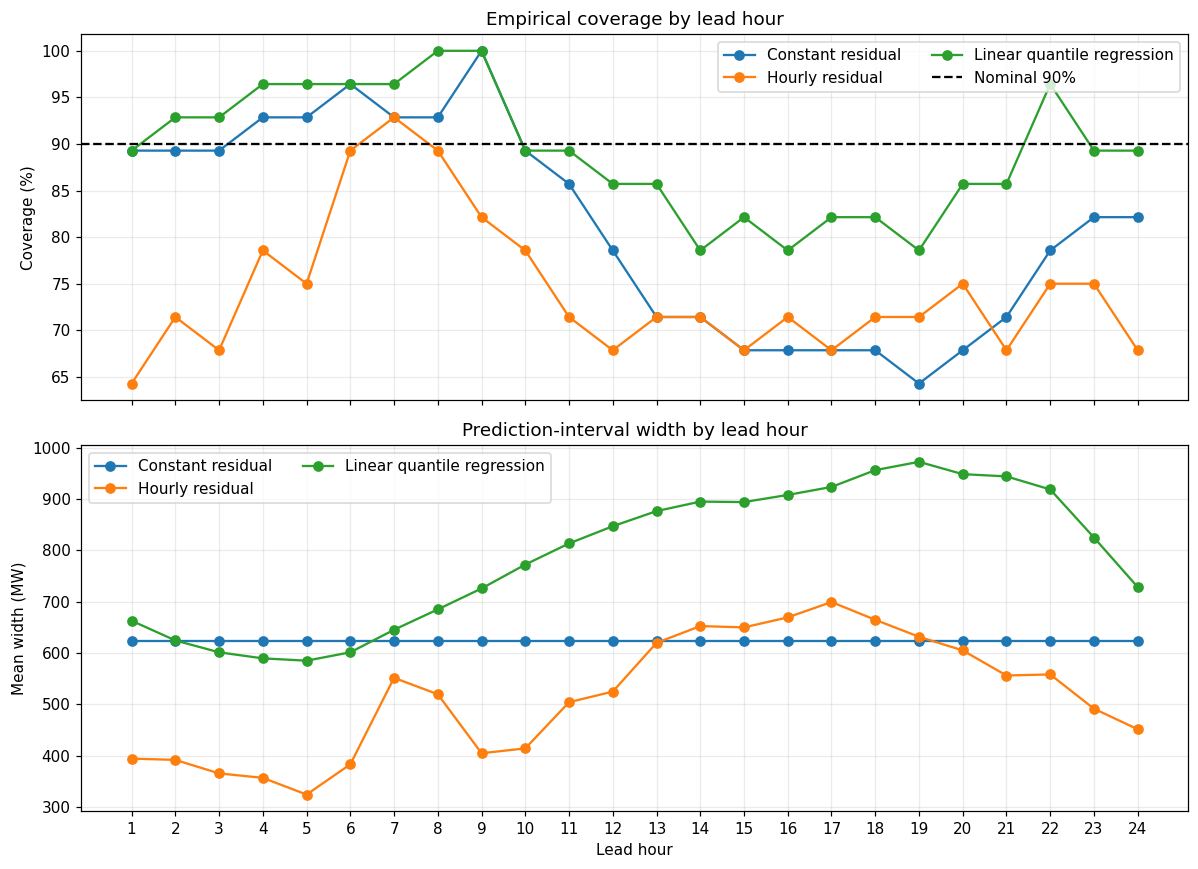

In [11]:
def diagnostics_by_lead(actual, lower, upper):
    diagnostic_frame = pd.DataFrame({
        "actual": actual,
        "lower": lower,
        "upper": upper,
        "lead_hour": actual.index.hour + 1,
    })

    rows = []
    for lead_hour, group in diagnostic_frame.groupby("lead_hour"):
        rows.append({
            "Lead hour": lead_hour,
            "Coverage (%)": empirical_coverage(
                group["actual"], group["lower"], group["upper"]
            ),
            "Mean width (MW)": mean_interval_width(
                group["lower"], group["upper"]
            ),
        })
    return pd.DataFrame(rows).set_index("Lead hour")


lead_diagnostics = {
    method_name: diagnostics_by_lead(test["target"], lower, upper)
    for method_name, (lower, upper) in intervals.items()
}

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for method_name, diagnostic_frame in lead_diagnostics.items():
    axes[0].plot(
        diagnostic_frame.index,
        diagnostic_frame["Coverage (%)"],
        marker="o",
        label=method_name,
    )
    axes[1].plot(
        diagnostic_frame.index,
        diagnostic_frame["Mean width (MW)"],
        marker="o",
        label=method_name,
    )

axes[0].axhline(100 * NOMINAL_COVERAGE, color="black", linestyle="--", label="Nominal 90%")
axes[0].set(title="Empirical coverage by lead hour", ylabel="Coverage (%)")
axes[0].legend(ncol=2)
axes[1].set(title="Prediction-interval width by lead hour", xlabel="Lead hour", ylabel="Mean width (MW)")
axes[1].legend(ncol=2)
axes[1].set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

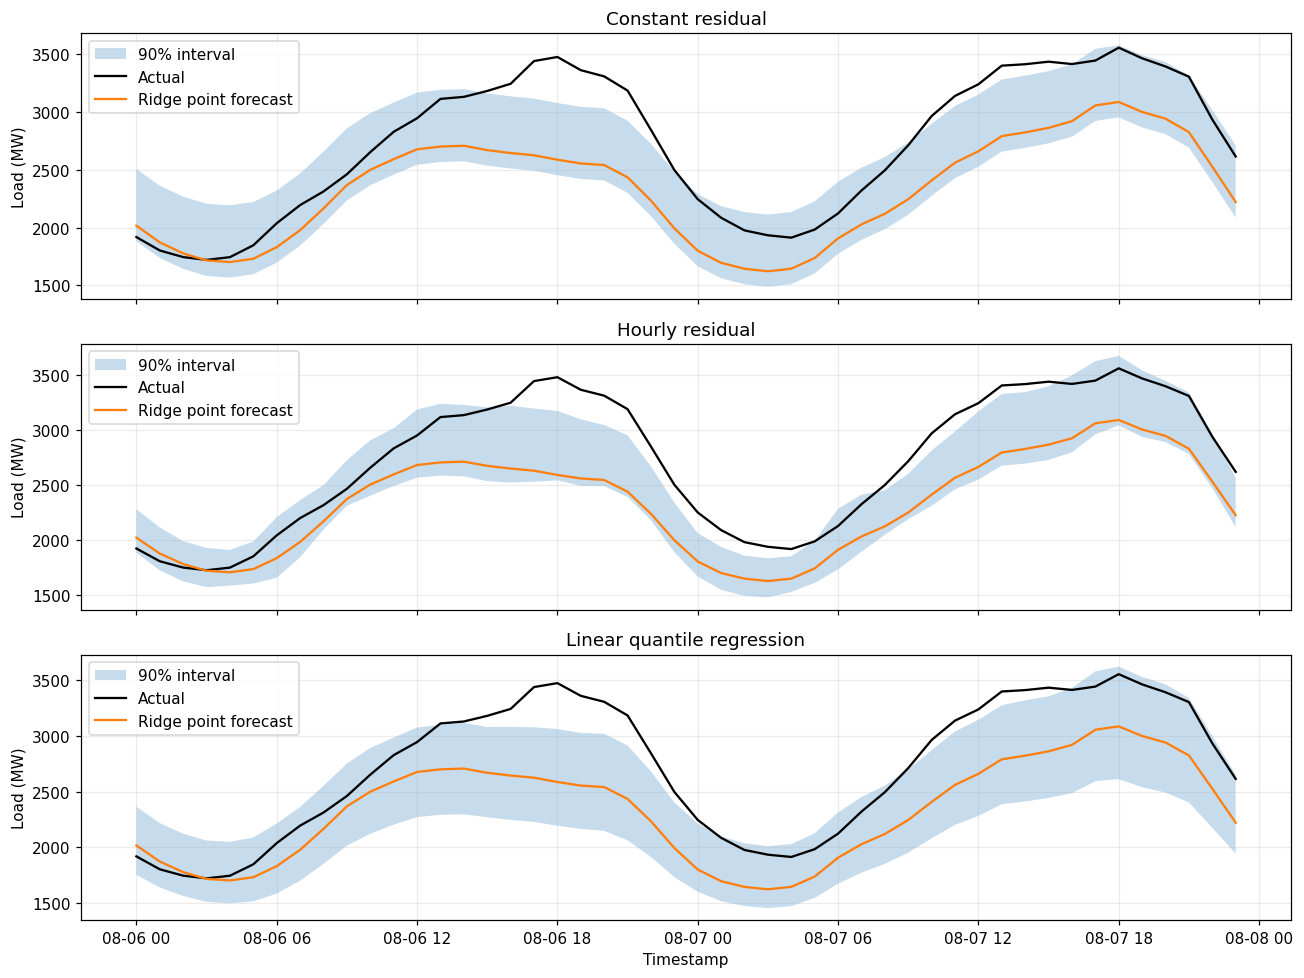

In [12]:
fig, axes = plt.subplots(len(intervals), 1, figsize=(12, 9), sharex=True)

for ax, (method_name, (lower, upper)) in zip(axes, intervals.items()):
    ax.fill_between(
        plot_index,
        lower.loc[plot_index].to_numpy(),
        upper.loc[plot_index].to_numpy(),
        alpha=0.25,
        label="90% interval",
    )
    ax.plot(plot_index, test.loc[plot_index, "target"], color="black", label="Actual")
    ax.plot(plot_index, test_point.loc[plot_index], color="tab:orange", label="Ridge point forecast")
    ax.set(title=method_name, ylabel="Load (MW)")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## 6. Task 4 — Gaussian temporal scenarios

Prediction intervals describe uncertainty at each hour separately. They do not specify which hourly outcomes may occur together. We now represent each calibration day as one 24-hour residual trajectory.

Two deliberately simple Gaussian approaches are compared:

1. **Independent Gaussian errors:** estimate a mean and standard deviation for each lead hour, then sample every hour independently.
2. **Multivariate Gaussian errors:** estimate a 24-element mean vector and a $24 \times 24$ covariance matrix, then sample a complete residual trajectory.

Both methods add sampled residuals to the point forecast. The multivariate model can reproduce correlations between adjacent hours, although a Gaussian distribution remains a strong approximation and the calibration sample contains only 31 daily trajectories.

In [13]:
def independent_gaussian_scenarios(
    point_trajectory, residual_matrix, n_scenarios, random_state
):
    rng = np.random.default_rng(random_state)
    residual_mean = residual_matrix.mean(axis=0)
    residual_std = residual_matrix.std(axis=0, ddof=1)
    sampled_errors = rng.normal(
        loc=residual_mean,
        scale=residual_std,
        size=(n_scenarios, residual_matrix.shape[1]),
    )
    scenarios = point_trajectory[np.newaxis, :] + sampled_errors
    return np.maximum(scenarios, 0)


def multivariate_gaussian_scenarios(
    point_trajectory, residual_matrix, n_scenarios, random_state
):
    rng = np.random.default_rng(random_state)
    residual_mean = residual_matrix.mean(axis=0)
    residual_covariance = np.cov(residual_matrix, rowvar=False)
    sampled_errors = rng.multivariate_normal(
        mean=residual_mean,
        cov=residual_covariance,
        size=n_scenarios,
        method="svd",
    )
    scenarios = point_trajectory[np.newaxis, :] + sampled_errors
    return np.maximum(scenarios, 0)

In [14]:
calibration_residual_matrix = calibration_residuals.to_numpy().reshape(-1, 24)

scenario_day = pd.Timestamp("2007-08-08")
scenario_index = pd.date_range(scenario_day, periods=24, freq="h")
point_trajectory = test_point.loc[scenario_index].to_numpy()
actual_trajectory = test.loc[scenario_index, "target"].to_numpy()

N_SCENARIOS = 500
independent_scenarios = independent_gaussian_scenarios(
    point_trajectory,
    calibration_residual_matrix,
    n_scenarios=N_SCENARIOS,
    random_state=42,
)
multivariate_scenarios = multivariate_gaussian_scenarios(
    point_trajectory,
    calibration_residual_matrix,
    n_scenarios=N_SCENARIOS,
    random_state=42,
)

assert independent_scenarios.shape == (N_SCENARIOS, 24)
assert multivariate_scenarios.shape == (N_SCENARIOS, 24)
assert np.all(independent_scenarios >= 0)
assert np.all(multivariate_scenarios >= 0)

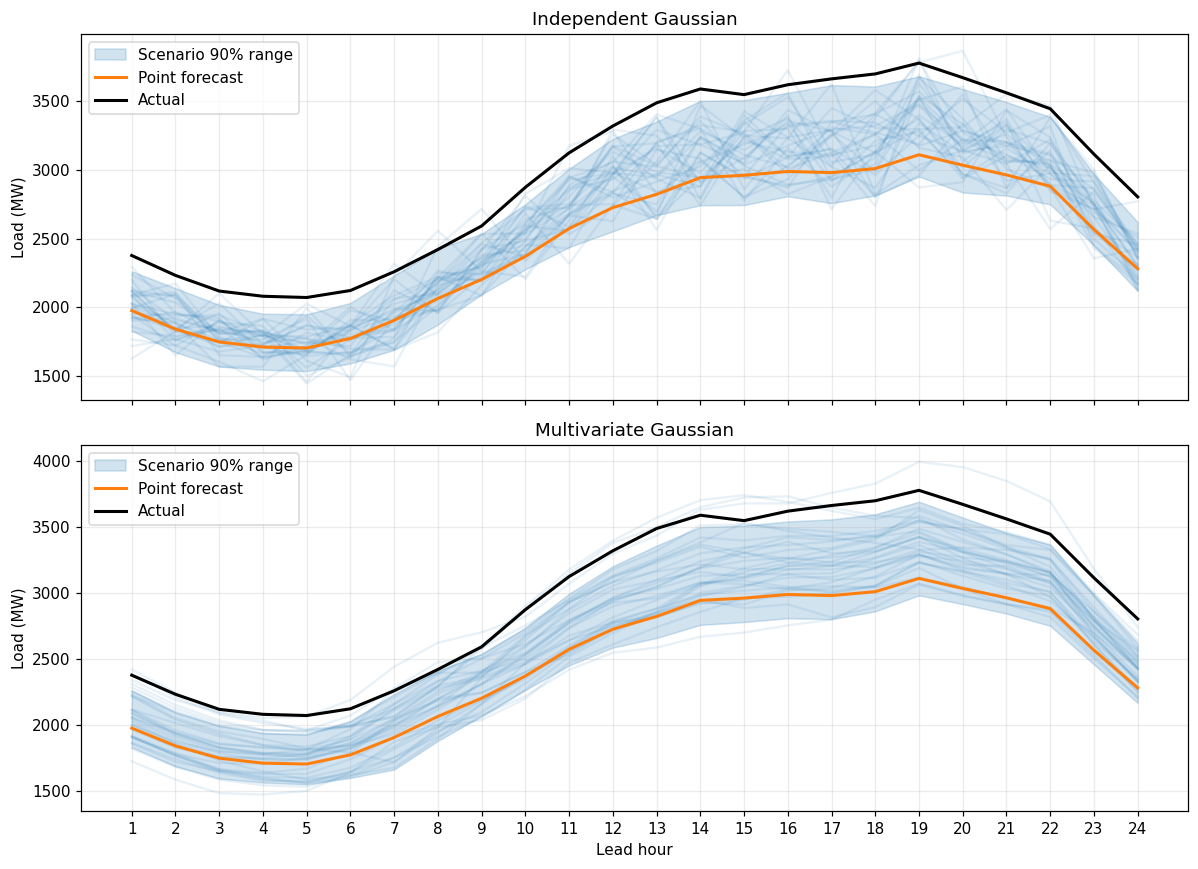

In [15]:
lead_hours = np.arange(1, 25)
scenario_sets = {
    "Independent Gaussian": independent_scenarios,
    "Multivariate Gaussian": multivariate_scenarios,
}

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, (method_name, scenario_values) in zip(axes, scenario_sets.items()):
    for scenario in scenario_values[:30]:
        ax.plot(lead_hours, scenario, color="tab:blue", alpha=0.10)

    lower_scenario = np.quantile(scenario_values, 0.05, axis=0)
    upper_scenario = np.quantile(scenario_values, 0.95, axis=0)
    ax.fill_between(
        lead_hours,
        lower_scenario,
        upper_scenario,
        color="tab:blue",
        alpha=0.20,
        label="Scenario 90% range",
    )
    ax.plot(lead_hours, point_trajectory, color="tab:orange", linewidth=2, label="Point forecast")
    ax.plot(lead_hours, actual_trajectory, color="black", linewidth=2, label="Actual")
    ax.set(title=method_name, ylabel="Load (MW)")
    ax.legend(loc="upper left")

axes[-1].set(xlabel="Lead hour", xticks=lead_hours)
plt.tight_layout()
plt.show()

In [16]:
def mean_adjacent_hour_correlation(residual_trajectories):
    correlation_matrix = np.corrcoef(residual_trajectories, rowvar=False)
    return np.mean(np.diag(correlation_matrix, k=1))


scenario_dependence = pd.Series({
    "Calibration residuals": mean_adjacent_hour_correlation(
        calibration_residual_matrix
    ),
    "Independent Gaussian": mean_adjacent_hour_correlation(
        independent_scenarios - point_trajectory
    ),
    "Multivariate Gaussian": mean_adjacent_hour_correlation(
        multivariate_scenarios - point_trajectory
    ),
}, name="Mean adjacent-hour residual correlation")

scenario_dependence.to_frame().round(2)

,Mean adjacent-hour residual correlation
Calibration residuals,0.97
Independent Gaussian,0.02
Multivariate Gaussian,0.96


## 7. PV point and probabilistic forecasting

We now use `gefcom2014_solar_zone3.csv`, a cleaned extract from the GEFCom2014 solar track. The competition data contain normalised PV power for three Australian zones and 24-hour ECMWF weather-forecast trajectories issued at 00:00 UTC. We use Zone 3 because its PV output has the strongest contemporaneous relationship with the derived surface-solar-radiation forecast. The precise plant locations are not disclosed. The source timestamps have no explicit offset; we interpret them as UTC because daylight spans the evening and early-morning UTC hours and the mean solar peak occurs near 02:00 UTC, which is consistent with midday in eastern Australia.

The source weather fields are genuine forecasts. The compact extract gives the variables descriptive names while retaining the accumulated radiation and precipitation fields. For accumulated variables, a value at lead $h$ represents the total since the forecast origin. We therefore difference consecutive lead times within each 24-hour trajectory and divide accumulated energy by 3600 seconds to obtain hourly mean flux in $\mathrm{W/m^2}$. At lead 1, the accumulated value is already the increment since the 00:00 forecast origin. Tiny negative differences caused by numerical precision are clipped to zero.

The source identifiers map to ECMWF parameters as follows:

| Source | Forecast variable |
|---|---|
| `VAR78`, `VAR79` | total-column cloud liquid water and ice water |
| `VAR134`, `VAR157`, `VAR164` | surface pressure, relative humidity and total cloud cover |
| `VAR165`, `VAR166`, `VAR167` | 10 m wind components and 2 m air temperature |
| `VAR169`, `VAR175`, `VAR178` | accumulated surface solar, surface thermal and top net solar radiation |
| `VAR228` | accumulated total precipitation |

The cleaned CSV uses descriptive, unit-bearing column names and also provides derived wind speed, hourly radiation fluxes and hourly precipitation. The original anonymous names are documented in `data/tutorial_4_2/README.md`.

The PV data add two physical requirements:

- normalised power should not be negative or exceed 1 p.u.; and
- power must be zero at night.

Because the competition does not publish the site coordinates, `is_daylight_forecast` is based only on forecast surface solar radiation exceeding $1\ \mathrm{W/m^2}$. It does not use realised PV output and therefore avoids leakage. See `data/tutorial_4_2/README.md` for the complete variable mapping and provenance.

MAPE is not used for PV because its denominator is zero at night and can be very small near sunrise and sunset.


In [17]:
PV_DATA_PATH = Path("data") / "tutorial_4_2" / "gefcom2014_solar_zone3.csv"

pv_data = pd.read_csv(PV_DATA_PATH)
pv_data["timestamp_utc"] = pd.to_datetime(pv_data["timestamp_utc"], utc=True)
pv_data["forecast_issue_time_utc"] = pd.to_datetime(
    pv_data["forecast_issue_time_utc"], utc=True
)
pv_data = pv_data.set_index("timestamp_utc").sort_index()

expected_pv_index = pd.date_range(
    "2012-04-01 01:00", "2014-07-01 00:00", freq="h", tz="UTC"
)

assert pv_data.index.equals(expected_pv_index)
assert pv_data.index.is_unique
assert (pv_data["solar_power_pu"] >= 0).all()
assert set(pv_data["forecast_lead_hours"].unique()) == set(range(1, 25))
assert (pv_data["forecast_issue_time_utc"].dt.hour == 0).all()
assert not pv_data.isna().any().any()

pv_quality_summary = pd.Series({
    "Rows": len(pv_data),
    "Missing timestamps": len(expected_pv_index.difference(pv_data.index)),
    "Duplicate timestamps": pv_data.index.duplicated().sum(),
    "Missing values": int(pv_data.isna().sum().sum()),
    "Minimum normalised PV power (p.u.)": pv_data["solar_power_pu"].min(),
    "Maximum normalised PV power (p.u.)": pv_data["solar_power_pu"].max(),
    "Forecast-daylight hours": int(pv_data["is_daylight_forecast"].sum()),
})
display(pv_quality_summary.to_frame("Value"))


,Value
Rows,19704.00000
Missing timestamps,0.00000
Duplicate timestamps,0.00000
Missing values,0.00000
Minimum normalised PV power (p.u.),0.00000
Maximum normalised PV power (p.u.),1.00355
Forecast-daylight hours,10156.00000


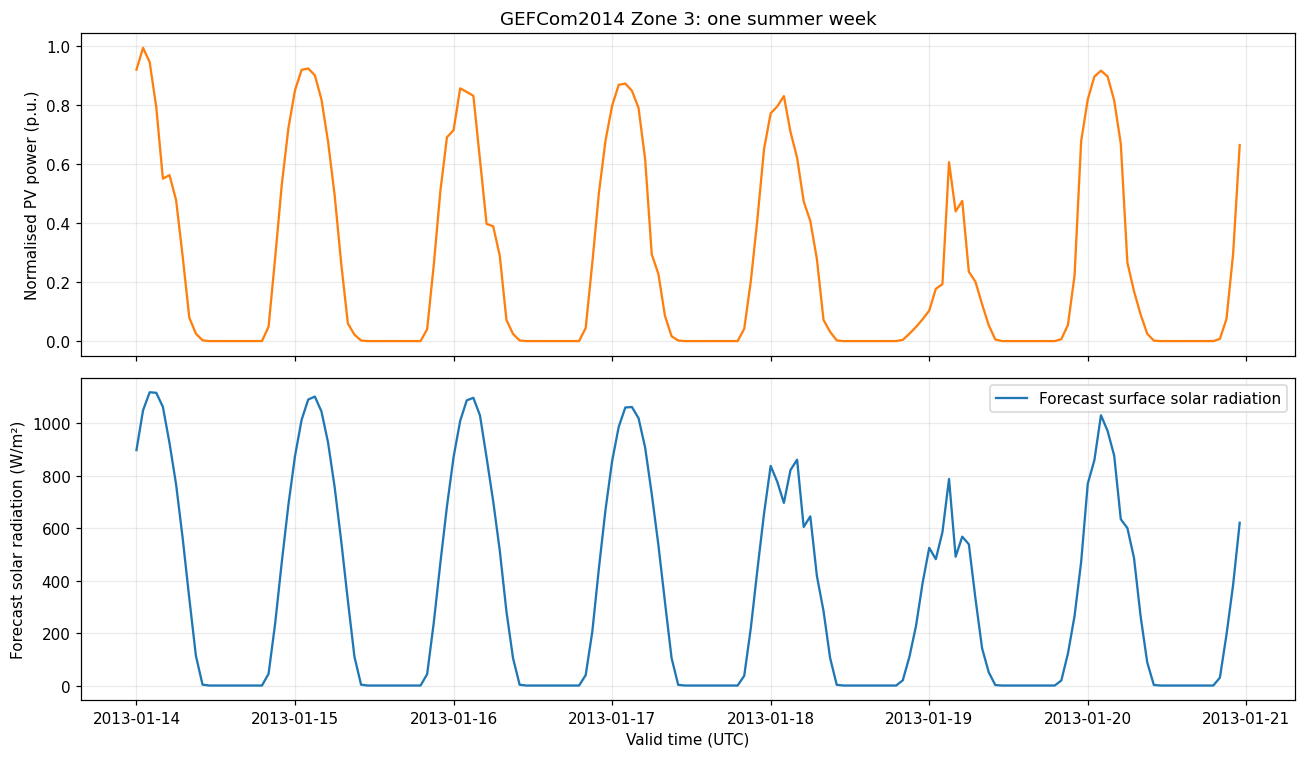

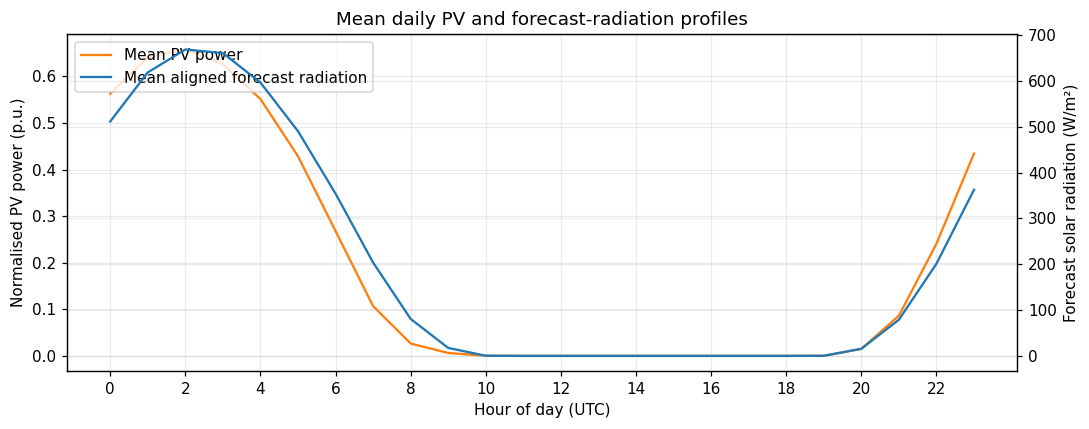

In [18]:
example_week = pv_data.loc["2013-01-14":"2013-01-20 23:00"]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(example_week.index, example_week["solar_power_pu"], color="tab:orange")
axes[0].set_ylabel("Normalised PV power (p.u.)")
axes[0].set_title("GEFCom2014 Zone 3: one summer week")

axes[1].plot(
    example_week.index,
    example_week["forecast_surface_solar_radiation_w_m2"],
    color="tab:blue",
    label="Forecast surface solar radiation",
)
axes[1].set_ylabel("Forecast solar radiation (W/m²)")
axes[1].set_xlabel("Valid time (UTC)")
axes[1].legend()
plt.tight_layout()
plt.show()

mean_profiles = pv_data.groupby(pv_data.index.hour)[
    ["solar_power_pu", "forecast_surface_solar_radiation_w_m2"]
].mean()

fig, ax_power = plt.subplots(figsize=(10, 4))
ax_radiation = ax_power.twinx()
ax_power.plot(mean_profiles.index, mean_profiles["solar_power_pu"], color="tab:orange", label="Mean PV power")
ax_radiation.plot(
    mean_profiles.index,
    mean_profiles["forecast_surface_solar_radiation_w_m2"],
    color="tab:blue",
    label="Mean aligned forecast radiation",
)
ax_power.set(xlabel="Hour of day (UTC)", ylabel="Normalised PV power (p.u.)", xticks=range(0, 24, 2))
ax_radiation.set_ylabel("Forecast solar radiation (W/m²)")
lines = ax_power.lines + ax_radiation.lines
ax_power.legend(lines, [line.get_label() for line in lines], loc="upper left")
ax_power.set_title("Mean daily PV and forecast-radiation profiles")
plt.tight_layout()
plt.show()


### Task 5 — Compare two simple linear PV models

We forecast the full test period directly from target-hour weather forecasts and calendar information. No realised test-period PV values are used as predictors.

Compare:

1. one pooled linear regression with a few explicit interaction terms; and
2. 24 separate linear regressions, one for each UTC hour.

The pooled model shares information across the day. Its interactions allow the radiation slope to change with cloud cover, temperature and time of day. The hourly approach is easy to interpret but fits each model using only one twenty-fourth of the training rows. We select between them on a validation period, not on the final test period.

The chronological roles are:

- April 2012–March 2013: fit the two candidate point models;
- April–June 2013: compare and select the formulation;
- July–September 2013: calibrate prediction intervals; and
- October–December 2013: final test.

After selecting the formulation, we refit it using all data available through June 2013 before generating calibration and test forecasts.


In [19]:
def make_pv_features(data):
    features = data.copy()
    hour = features.index.hour
    day_of_year = features.index.dayofyear

    features["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    features["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    features["day_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
    features["day_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)

    irradiance = features["forecast_surface_solar_radiation_w_m2"]
    features["irradiance_x_cloud"] = (
        irradiance * features["forecast_total_cloud_cover_fraction"]
    )
    features["irradiance_x_temperature"] = (
        irradiance * features["forecast_air_temperature_c"]
    )
    features["irradiance_x_hour_sin"] = irradiance * features["hour_sin"]
    features["irradiance_x_hour_cos"] = irradiance * features["hour_cos"]
    return features


HOURLY_PV_FEATURES = [
    "forecast_surface_solar_radiation_w_m2",
    "forecast_air_temperature_c",
    "forecast_total_cloud_cover_fraction",
    "forecast_relative_humidity_pct",
    "forecast_wind_speed_10m_m_s",
    "forecast_total_column_cloud_liquid_water_kg_m2",
    "day_sin",
    "day_cos",
]

POOLED_PV_FEATURES = HOURLY_PV_FEATURES + [
    "hour_sin",
    "hour_cos",
    "irradiance_x_cloud",
    "irradiance_x_temperature",
    "irradiance_x_hour_sin",
    "irradiance_x_hour_cos",
]

pv_features = make_pv_features(pv_data)
issue_dates = pv_features["forecast_issue_time_utc"]
pv_train = pv_features.loc[issue_dates < "2013-04-01"]
pv_validation = pv_features.loc[
    (issue_dates >= "2013-04-01") & (issue_dates < "2013-07-01")
]
pv_calibration = pv_features.loc[
    (issue_dates >= "2013-07-01") & (issue_dates < "2013-10-01")
]
pv_test = pv_features.loc[
    (issue_dates >= "2013-10-01") & (issue_dates < "2014-01-01")
]

pd.DataFrame({
    "Start": [frame.index.min() for frame in [pv_train, pv_validation, pv_calibration, pv_test]],
    "End": [frame.index.max() for frame in [pv_train, pv_validation, pv_calibration, pv_test]],
    "Hours": [len(frame) for frame in [pv_train, pv_validation, pv_calibration, pv_test]],
}, index=["Training", "Validation", "Calibration", "Test"])


,Start,End,Hours
Training,2012-04-01 01:00:00+00:00,2013-04-01 00:00:00+00:00,8760
Validation,2013-04-01 01:00:00+00:00,2013-07-01 00:00:00+00:00,2184
Calibration,2013-07-01 01:00:00+00:00,2013-10-01 00:00:00+00:00,2208
Test,2013-10-01 01:00:00+00:00,2014-01-01 00:00:00+00:00,2208


In [20]:
def fit_hourly_linear_models(training_data, feature_columns):
    models = {}
    for hour in range(24):
        hour_rows = training_data.index.hour == hour
        model = LinearRegression()
        model.fit(
            training_data.loc[hour_rows, feature_columns],
            training_data.loc[hour_rows, "solar_power_pu"],
        )
        models[hour] = model
    return models


def predict_hourly_linear_models(models, forecast_data, feature_columns):
    forecast = pd.Series(index=forecast_data.index, dtype=float, name="PV forecast")
    for hour, model in models.items():
        hour_rows = forecast_data.index.hour == hour
        forecast.loc[hour_rows] = model.predict(
            forecast_data.loc[hour_rows, feature_columns]
        )
    return forecast


pooled_candidate = LinearRegression()
pooled_candidate.fit(pv_train[POOLED_PV_FEATURES], pv_train["solar_power_pu"])
pooled_validation_raw = pd.Series(
    pooled_candidate.predict(pv_validation[POOLED_PV_FEATURES]),
    index=pv_validation.index,
    name="Pooled interactions",
)

hourly_candidates = fit_hourly_linear_models(pv_train, HOURLY_PV_FEATURES)
hourly_validation_raw = predict_hourly_linear_models(
    hourly_candidates, pv_validation, HOURLY_PV_FEATURES
).rename("24 hourly models")


### Task 6 — Apply PV physical constraints

Ordinary linear regression does not know the feasible range of PV power. A raw forecast can therefore be negative or positive at night. These are distinct mistakes: projecting negative values to zero still leaves any positive night-time values untouched.

Apply the constraints in this order:

$$
\hat{p}^{\mathrm{physical}}_t =
\begin{cases}
0, & \text{if the Sun is below the horizon},\\
\min\!\left(p_{\max},\max(0,\hat{p}_t)\right), & \text{during daylight}.
\end{cases}
$$

Because the competition target is normalised, we use 1 p.u. as $p_{\max}$. The source contains a few observations marginally above 1 because of normalisation and rounding; these are retained. Compare the candidates after this common post-processing step, select the lower validation RMSE, and only then evaluate the chosen formulation on the untouched test period.


In [21]:
def apply_pv_constraints(point_forecast, forecast_data):
    corrected = point_forecast.copy()
    corrected = corrected.clip(lower=0, upper=1.0)
    corrected.loc[forecast_data["is_daylight_forecast"].eq(0)] = 0
    return corrected


def rmse(actual, forecast):
    return np.sqrt(np.mean((np.asarray(actual) - np.asarray(forecast)) ** 2))


def mae(actual, forecast):
    return np.mean(np.abs(np.asarray(actual) - np.asarray(forecast)))


raw_validation_forecasts = {
    "Pooled interactions": pooled_validation_raw,
    "24 hourly models": hourly_validation_raw,
}

validation_rows = {}
for model_name, raw_forecast in raw_validation_forecasts.items():
    corrected_forecast = apply_pv_constraints(raw_forecast, pv_validation)
    daylight = pv_validation["is_daylight_forecast"].eq(1)
    validation_rows[model_name] = {
        "Corrected RMSE (p.u.)": rmse(pv_validation["solar_power_pu"], corrected_forecast),
        "Corrected MAE (p.u.)": mae(pv_validation["solar_power_pu"], corrected_forecast),
        "Daylight RMSE (p.u.)": rmse(
            pv_validation.loc[daylight, "solar_power_pu"],
            corrected_forecast.loc[daylight],
        ),
        "Raw negative values": int((raw_forecast < 0).sum()),
        "Raw positive night values": int(
            (raw_forecast.loc[~daylight] > 0).sum()
        ),
    }

pv_validation_comparison = pd.DataFrame(validation_rows).T
selected_pv_model = pv_validation_comparison["Corrected RMSE (p.u.)"].idxmin()
display(pv_validation_comparison.round(3))
print("Selected using validation RMSE:", selected_pv_model)


,Corrected RMSE (p.u.),Corrected MAE (p.u.),Daylight RMSE (p.u.),Raw negative values,Raw positive night values
Pooled interactions,0.081,0.042,0.120,287.0,915.0
24 hourly models,0.076,0.035,0.114,309.0,173.0


Selected using validation RMSE: 24 hourly models


In [22]:
# Selection used only the validation period. Refit the selected formulation on
# all data available before calibration, then leave calibration and test untouched.
pv_point_fit_data = pd.concat([pv_train, pv_validation])

if selected_pv_model == "Pooled interactions":
    final_pv_model = LinearRegression()
    final_pv_model.fit(
        pv_point_fit_data[POOLED_PV_FEATURES],
        pv_point_fit_data["solar_power_pu"],
    )
    pv_calibration_raw = pd.Series(
        final_pv_model.predict(pv_calibration[POOLED_PV_FEATURES]),
        index=pv_calibration.index,
    )
    pv_test_raw = pd.Series(
        final_pv_model.predict(pv_test[POOLED_PV_FEATURES]),
        index=pv_test.index,
    )
else:
    final_pv_model = fit_hourly_linear_models(
        pv_point_fit_data, HOURLY_PV_FEATURES
    )
    pv_calibration_raw = predict_hourly_linear_models(
        final_pv_model, pv_calibration, HOURLY_PV_FEATURES
    )
    pv_test_raw = predict_hourly_linear_models(
        final_pv_model, pv_test, HOURLY_PV_FEATURES
    )

pv_calibration_point = apply_pv_constraints(pv_calibration_raw, pv_calibration)
pv_test_point = apply_pv_constraints(pv_test_raw, pv_test)

pv_test_daylight = pv_test["is_daylight_forecast"].eq(1)
pv_point_summary = pd.DataFrame({
    "Raw linear forecast": {
        "Full-day RMSE (p.u.)": rmse(pv_test["solar_power_pu"], pv_test_raw),
        "Full-day MAE (p.u.)": mae(pv_test["solar_power_pu"], pv_test_raw),
        "Daylight RMSE (p.u.)": rmse(
            pv_test.loc[pv_test_daylight, "solar_power_pu"],
            pv_test_raw.loc[pv_test_daylight],
        ),
        "Negative values": int((pv_test_raw < 0).sum()),
        "Positive night values": int(
            (pv_test_raw.loc[~pv_test_daylight] > 0).sum()
        ),
    },
    "Physically constrained": {
        "Full-day RMSE (p.u.)": rmse(pv_test["solar_power_pu"], pv_test_point),
        "Full-day MAE (p.u.)": mae(pv_test["solar_power_pu"], pv_test_point),
        "Daylight RMSE (p.u.)": rmse(
            pv_test.loc[pv_test_daylight, "solar_power_pu"],
            pv_test_point.loc[pv_test_daylight],
        ),
        "Negative values": int((pv_test_point < 0).sum()),
        "Positive night values": int(
            (pv_test_point.loc[~pv_test_daylight] > 0).sum()
        ),
    },
}).T

display(pv_point_summary.round(3))


,Full-day RMSE (p.u.),Full-day MAE (p.u.),Daylight RMSE (p.u.),Negative values,Positive night values
Raw linear forecast,0.082,0.04,0.106,13.0,135.0
Physically constrained,0.081,0.04,0.105,0.0,0.0


### Task 7 — Why one interval for all 24 hours fails for PV

Use September–October residuals from the physically constrained point forecast to form 90% intervals for November–December.

First apply one pair of residual quantiles to every hour. This is a deliberately poor PV practice: the resulting interval has the same additive width at midnight and noon. Then compare it with residual quantiles estimated separately for each hour of day.

Finally, apply the PV constraints to **both** bounds. At night, setting only the lower bound to zero is not enough: the complete interval must collapse to $[0,0]$. Report coverage and width for both the full day and daylight hours. Full-day coverage can look deceptively good because the many zero night-time observations are easy to cover.


In [23]:
def apply_pv_interval_constraints(lower, upper, forecast_data):
    corrected_lower = lower.clip(lower=0, upper=1.0)
    corrected_upper = upper.clip(lower=0, upper=1.0)
    night = forecast_data["is_daylight_forecast"].eq(0)
    corrected_lower.loc[night] = 0
    corrected_upper.loc[night] = 0
    return corrected_lower, corrected_upper


pv_calibration_residuals = (
    pv_calibration["solar_power_pu"] - pv_calibration_point
)

pv_constant_lower_raw, pv_constant_upper_raw = constant_residual_interval(
    pv_test_point, pv_calibration_residuals, alpha=ALPHA
)
pv_hourly_lower_raw, pv_hourly_upper_raw = hourly_residual_interval(
    pv_test_point, pv_calibration_residuals, alpha=ALPHA
)

pv_constant_lower, pv_constant_upper = apply_pv_interval_constraints(
    pv_constant_lower_raw, pv_constant_upper_raw, pv_test
)
pv_hourly_lower, pv_hourly_upper = apply_pv_interval_constraints(
    pv_hourly_lower_raw, pv_hourly_upper_raw, pv_test
)


### Task 8 — Transfer quantile regression to PV

Fit the 5th, 50th and 95th conditional quantiles using the selected pooled feature set. The pre-test data can all be used here: unlike a residual interval, direct quantile regression does not need a separate residual-calibration sample.

Linear quantile forecasts can cross and can violate PV limits. As in the load exercise, first order the three predicted quantiles at each timestamp. Then apply the same 0–1 p.u. and night-time constraints to every quantile. Compare the resulting 90% interval with the residual-based alternatives.


In [24]:
pv_quantile_fit_data = pd.concat([
    pv_train, pv_validation, pv_calibration
])
pv_raw_quantiles = pd.DataFrame(index=pv_test.index)
pv_quantile_models = {}

for quantile in QUANTILES:
    model = make_pipeline(
        StandardScaler(),
        QuantileRegressor(quantile=quantile, alpha=0.01, solver="highs"),
    )
    model.fit(
        pv_quantile_fit_data[POOLED_PV_FEATURES],
        pv_quantile_fit_data["solar_power_pu"],
    )
    pv_quantile_models[quantile] = model
    pv_raw_quantiles[quantile] = model.predict(pv_test[POOLED_PV_FEATURES])

pv_crossing_mask = (
    (pv_raw_quantiles[0.05] > pv_raw_quantiles[0.50])
    | (pv_raw_quantiles[0.50] > pv_raw_quantiles[0.95])
)
print("PV timestamps with crossing raw quantiles:", pv_crossing_mask.sum())

pv_ordered_quantiles = pd.DataFrame(
    np.sort(pv_raw_quantiles.to_numpy(), axis=1),
    index=pv_test.index,
    columns=QUANTILES,
)
pv_quantiles = pd.DataFrame(index=pv_test.index)
for quantile in QUANTILES:
    pv_quantiles[quantile] = apply_pv_constraints(
        pv_ordered_quantiles[quantile], pv_test
    )

pv_quantile_scores = pd.Series({
    "QS q=0.05": quantile_score(
        pv_test["solar_power_pu"], pv_quantiles[0.05], 0.05
    ),
    "QS q=0.50": quantile_score(
        pv_test["solar_power_pu"], pv_quantiles[0.50], 0.50
    ),
    "QS q=0.95": quantile_score(
        pv_test["solar_power_pu"], pv_quantiles[0.95], 0.95
    ),
    "90% interval score": interval_score(
        pv_test["solar_power_pu"],
        pv_quantiles[0.05],
        pv_quantiles[0.95],
        alpha=ALPHA,
    ),
})
display(pv_quantile_scores.round(3).to_frame("Score"))


PV timestamps with crossing raw quantiles: 77


,Score
QS q=0.05,0.008
QS q=0.50,0.026
QS q=0.95,0.006
90% interval score,0.282


In [25]:
pv_interval_variants = {
    "Constant residual — raw": (pv_constant_lower_raw, pv_constant_upper_raw),
    "Constant residual — physical": (pv_constant_lower, pv_constant_upper),
    "Hourly residual — raw": (pv_hourly_lower_raw, pv_hourly_upper_raw),
    "Hourly residual — physical": (pv_hourly_lower, pv_hourly_upper),
    "Linear quantile — physical": (pv_quantiles[0.05], pv_quantiles[0.95]),
}

pv_interval_rows = {}
for method_name, (lower, upper) in pv_interval_variants.items():
    pv_interval_rows[method_name] = {
        "Full-day coverage (%)": empirical_coverage(
            pv_test["solar_power_pu"], lower, upper
        ),
        "Full-day mean width (p.u.)": mean_interval_width(lower, upper),
        "Daylight coverage (%)": empirical_coverage(
            pv_test.loc[pv_test_daylight, "solar_power_pu"],
            lower.loc[pv_test_daylight],
            upper.loc[pv_test_daylight],
        ),
        "Daylight mean width (p.u.)": mean_interval_width(
            lower.loc[pv_test_daylight], upper.loc[pv_test_daylight]
        ),
        "Night mean width (p.u.)": mean_interval_width(
            lower.loc[~pv_test_daylight], upper.loc[~pv_test_daylight]
        ),
        "Negative lower bounds": int((lower < 0).sum()),
        "Positive night upper bounds": int(
            (upper.loc[~pv_test_daylight] > 0).sum()
        ),
    }

pv_interval_summary = pd.DataFrame(pv_interval_rows).T
display(pv_interval_summary.round(3))


,Full-day coverage (%),Full-day mean width (p.u.),Daylight coverage (%),Daylight mean width (p.u.),Night mean width (p.u.),Negative lower bounds,Positive night upper bounds
Constant residual — raw,92.120,0.297,86.858,0.297,0.297,1288.0,884.0
Constant residual — physical,88.134,0.152,86.782,0.253,0.000,0.0,0.0
Hourly residual — raw,76.404,0.194,67.221,0.323,0.000,28.0,10.0
Hourly residual — physical,76.359,0.184,67.145,0.307,0.000,0.0,0.0
Linear quantile — physical,92.437,0.257,93.958,0.429,0.000,0.0,0.0


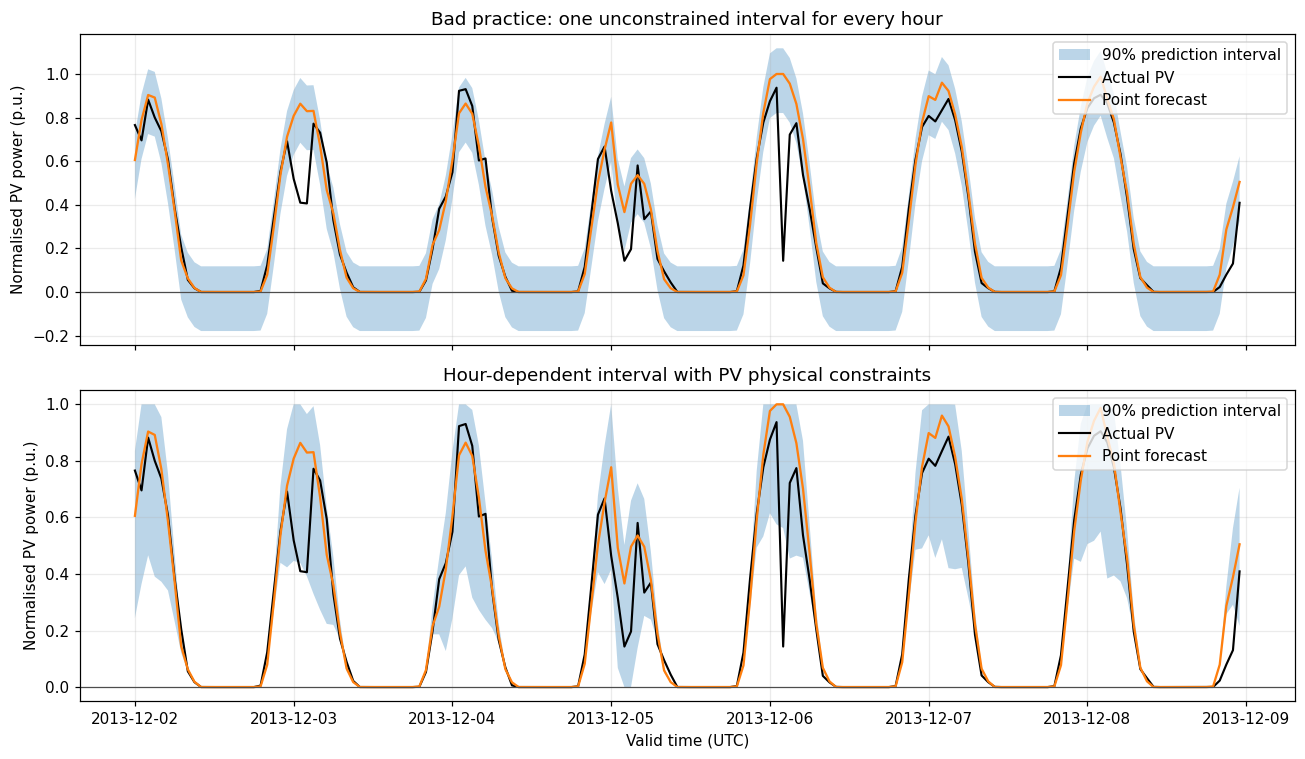

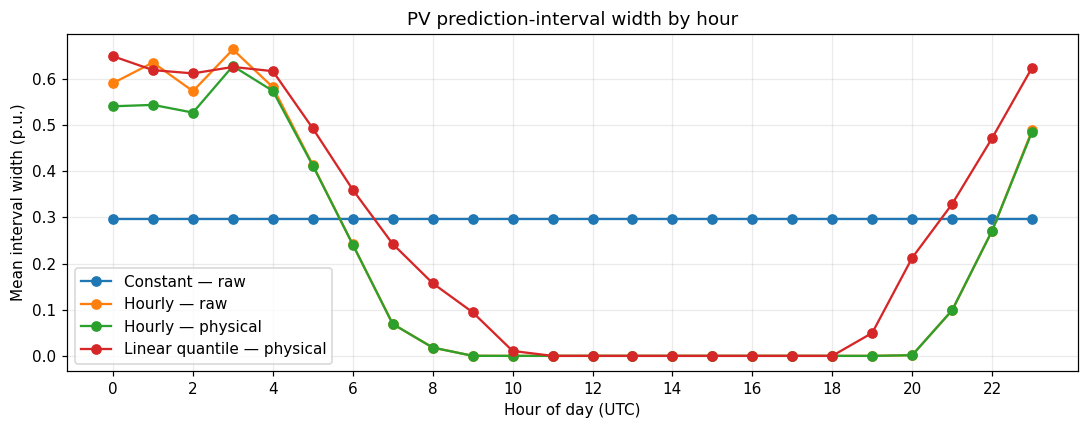

In [26]:
pv_interval_week = pv_test.loc["2013-12-02":"2013-12-08 23:00"].index

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
interval_examples = [
    (
        "Bad practice: one unconstrained interval for every hour",
        pv_constant_lower_raw,
        pv_constant_upper_raw,
    ),
    (
        "Hour-dependent interval with PV physical constraints",
        pv_hourly_lower,
        pv_hourly_upper,
    ),
]

for ax, (title, lower, upper) in zip(axes, interval_examples):
    ax.fill_between(
        pv_interval_week,
        lower.loc[pv_interval_week],
        upper.loc[pv_interval_week],
        alpha=0.3,
        label="90% prediction interval",
    )
    ax.plot(
        pv_interval_week,
        pv_test.loc[pv_interval_week, "solar_power_pu"],
        color="black",
        linewidth=1.4,
        label="Actual PV",
    )
    ax.plot(
        pv_interval_week,
        pv_test_point.loc[pv_interval_week],
        color="tab:orange",
        label="Point forecast",
    )
    ax.axhline(0, color="0.3", linewidth=0.8)
    ax.set(ylabel="Normalised PV power (p.u.)", title=title)
    ax.legend(loc="upper right")

axes[1].set_xlabel("Valid time (UTC)")
plt.tight_layout()
plt.show()

width_by_hour = pd.DataFrame({
    "Constant — raw": pv_constant_upper_raw - pv_constant_lower_raw,
    "Hourly — raw": pv_hourly_upper_raw - pv_hourly_lower_raw,
    "Hourly — physical": pv_hourly_upper - pv_hourly_lower,
    "Linear quantile — physical": pv_quantiles[0.95] - pv_quantiles[0.05],
}).groupby(pv_test.index.hour).mean()

width_by_hour.plot(figsize=(10, 4), marker="o")
plt.xlabel("Hour of day (UTC)")
plt.ylabel("Mean interval width (p.u.)")
plt.title("PV prediction-interval width by hour")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()


### Task 9 — Transfer Gaussian trajectories to PV

The load-scenario functions can also be applied to 24-hour PV residual vectors. Non-negative projection alone is still insufficient: a Gaussian draw may remain positive at night. Apply the 0–1 p.u. range and forecast-daylight mask to every scenario after sampling.

The independent and multivariate constructions retain their earlier interpretation. Physical projection makes trajectories feasible, but it does not create realistic temporal dependence; the multivariate residual covariance is still needed for coherent daylight errors.

The original forecast trajectories run from 01:00 to 00:00 UTC. Because the sites are in Australia, that window contains the end of one daylight period and the beginning of the next. For this visualisation, reorganise both the calibration residuals and the selected test data into 15:00–14:00 UTC windows. This spans one continuous Australian solar day: night, sunrise, daytime, sunset and night. It combines valid times from two consecutive forecast origins, but every predictor remains the weather forecast associated with its own valid time.


,Positive night values before mask,Positive night values after mask
Independent Gaussian,0,0
Multivariate Gaussian,0,0


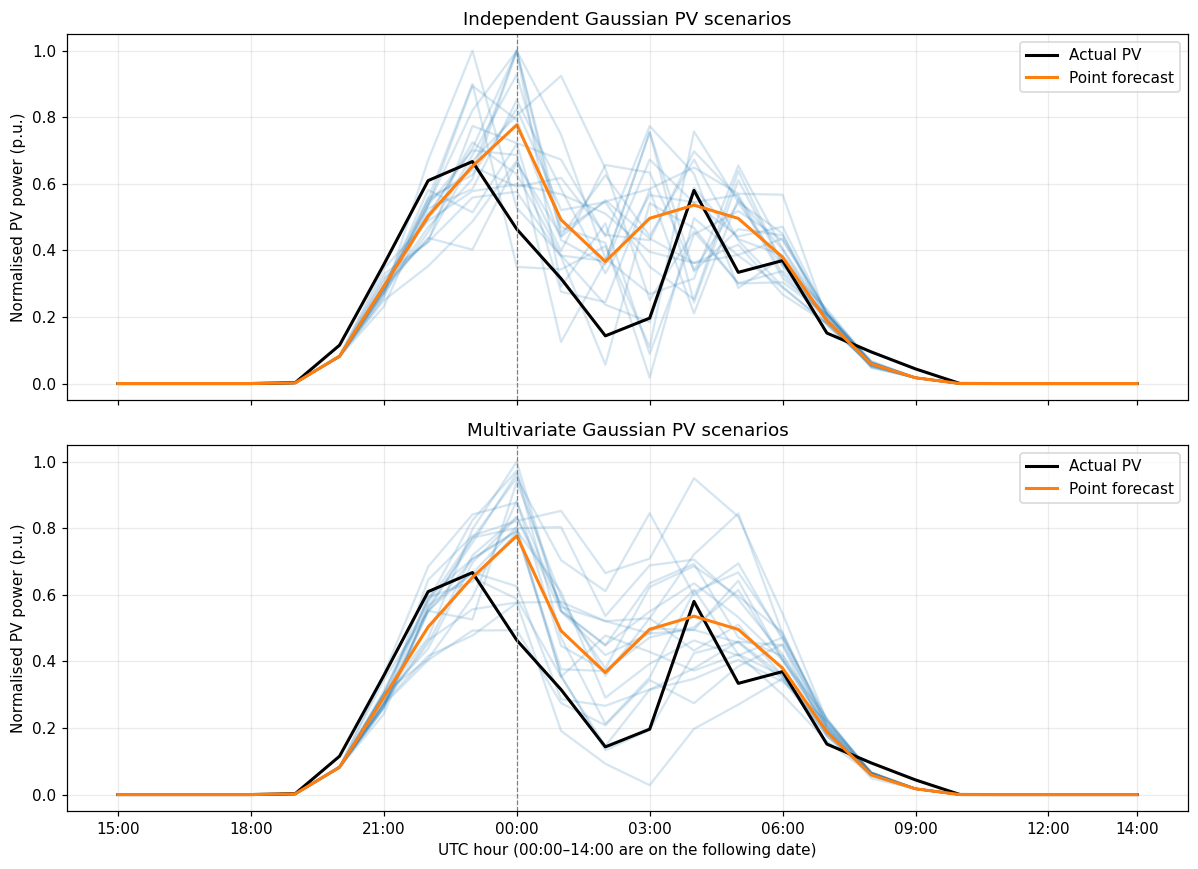

In [27]:
def apply_pv_scenario_constraints(scenarios, forecast_day):
    corrected = np.clip(scenarios.copy(), 0, 1.0)
    night_columns = forecast_day["is_daylight_forecast"].eq(0).to_numpy()
    corrected[:, night_columns] = 0
    return corrected


SOLAR_DAY_START_HOUR_UTC = 15

# Shift the grouping boundary to 15:00 UTC and keep only complete 24-hour
# windows. This makes each residual vector follow one Australian solar day.
pv_solar_day_key = (
    pv_calibration_residuals.index
    - pd.Timedelta(hours=SOLAR_DAY_START_HOUR_UTC)
).floor("D")
pv_complete_solar_day = (
    pv_calibration_residuals.groupby(pv_solar_day_key)
    .transform("size")
    .eq(24)
)
pv_calibration_residual_matrix = (
    pv_calibration_residuals.loc[pv_complete_solar_day]
    .to_numpy()
    .reshape(-1, 24)
)

pv_scenario_start = pd.Timestamp("2013-12-04 15:00", tz="UTC")
pv_scenario_index = pd.date_range(pv_scenario_start, periods=24, freq="h")
pv_scenario_frame = pv_test.loc[pv_scenario_index]
pv_point_trajectory = pv_test_point.loc[pv_scenario_frame.index].to_numpy()

pv_independent_nonnegative = independent_gaussian_scenarios(
    pv_point_trajectory,
    pv_calibration_residual_matrix,
    n_scenarios=100,
    random_state=42,
)
pv_multivariate_nonnegative = multivariate_gaussian_scenarios(
    pv_point_trajectory,
    pv_calibration_residual_matrix,
    n_scenarios=100,
    random_state=42,
)

pv_independent_scenarios = apply_pv_scenario_constraints(
    pv_independent_nonnegative, pv_scenario_frame
)
pv_multivariate_scenarios = apply_pv_scenario_constraints(
    pv_multivariate_nonnegative, pv_scenario_frame
)

scenario_night = pv_scenario_frame["is_daylight_forecast"].eq(0).to_numpy()
pv_scenario_checks = pd.DataFrame({
    "Independent Gaussian": {
        "Positive night values before mask": int(
            (pv_independent_nonnegative[:, scenario_night] > 0).sum()
        ),
        "Positive night values after mask": int(
            (pv_independent_scenarios[:, scenario_night] > 0).sum()
        ),
    },
    "Multivariate Gaussian": {
        "Positive night values before mask": int(
            (pv_multivariate_nonnegative[:, scenario_night] > 0).sum()
        ),
        "Positive night values after mask": int(
            (pv_multivariate_scenarios[:, scenario_night] > 0).sum()
        ),
    },
}).T
display(pv_scenario_checks)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, sharey=True)
pv_plot_hours = range(15, 39)
pv_tick_positions = [15, 18, 21, 24, 27, 30, 33, 36, 38]
pv_tick_labels = [f"{hour % 24:02d}:00" for hour in pv_tick_positions]

for ax, (title, scenario_array) in zip(
    axes,
    [
        ("Independent Gaussian PV scenarios", pv_independent_scenarios),
        ("Multivariate Gaussian PV scenarios", pv_multivariate_scenarios),
    ],
):
    for scenario in scenario_array[:20]:
        ax.plot(pv_plot_hours, scenario, color="tab:blue", alpha=0.18)
    ax.plot(
        pv_plot_hours,
        pv_scenario_frame["solar_power_pu"],
        color="black",
        linewidth=2,
        label="Actual PV",
    )
    ax.plot(
        pv_plot_hours,
        pv_point_trajectory,
        color="tab:orange",
        linewidth=2,
        label="Point forecast",
    )
    ax.axvline(24, color="0.5", linestyle="--", linewidth=0.8)
    ax.set(ylabel="Normalised PV power (p.u.)", title=title)
    ax.legend(loc="upper right")

axes[1].set(
    xlabel="UTC hour (00:00–14:00 are on the following date)",
    xticks=pv_tick_positions,
    xticklabels=pv_tick_labels,
)
plt.tight_layout()
plt.show()


## 8. Interpretation questions

1. **How do the constant and hour-dependent load intervals differ in coverage and width?**  
   The constant interval covers 81.25% of test observations with a mean width of 624.17 MW. The hourly interval is sharper at 515.88 MW, but its coverage falls to 74.26%, so the extra flexibility does not correct the July-to-August calibration shift in this example.

2. **Which of the three load interval methods has the best interval score on the test period?**  
   Linear quantile regression has the lowest interval score at 1011.83. Its 89.14% coverage is close to the nominal 90% and its mean width is 788.13 MW. The score balances sharpness with penalties for misses rather than rewarding coverage alone.

3. **Why must residual quantiles come from calibration data rather than test residuals?**  
   Test residuals contain the outcomes used for final evaluation. Using them to construct the intervals would leak test information and make coverage look too favourable.

4. **What does the coverage-by-lead plot reveal that overall coverage hides?**  
   Overall coverage can average together hours with undercoverage and hours with overcoverage. The lead plot identifies parts of the day where intervals are too narrow, too wide or systematically biased.

5. **Why do independently sampled Gaussian scenarios look less coherent than multivariate Gaussian scenarios?**  
   Independent sampling allows the error to jump without regard to neighbouring hours. Its mean adjacent-hour residual correlation is about 0.02, whereas the multivariate scenarios reproduce the calibration value of about 0.97 and therefore create more persistent deviations.

6. **What limitation follows from estimating a 24-dimensional covariance matrix from only 31 calibration days?**  
   The estimate is noisy and sensitive to unusual days. A longer calibration period, covariance regularisation or a lower-dimensional dependence model would be more stable.

7. **Which linear PV formulation was selected, and what evidence supports the choice?**  
   The 24 separate hourly models were selected because they have the lower physically constrained validation RMSE. Their daylight RMSE is also lower, and they produce far fewer positive night-time values before projection. The result is plausible because the relationship between forecast irradiance and normalised power changes substantially across the daily solar cycle.

8. **Why should physical constraints still be applied when the raw point-forecast violations are small?**  
   Even small violations are physically infeasible and may propagate into later decisions or probabilistic forecasts. The 0–1 p.u. projection and forecast-radiation daylight mask guarantee feasible outputs without presenting the otherwise accurate point forecast as a deliberately poor example.

9. **Why does one constant residual interval give a misleading picture of PV uncertainty at night?**  
   It adds the same residual offsets at every hour, producing negative lower bounds and positive upper bounds when true night-time PV is effectively fixed at zero. The physical interval should collapse to $[0,0]$ at night.

10. **Why should full-day and daylight-only PV coverage both be reported?**  
    Night contains many easy zero observations and can inflate full-day coverage. Daylight-only coverage reveals whether the interval represents uncertainty during the hours when PV power and forecast errors matter.

11. **Why is MAPE unsuitable for a complete PV time series?**  
    The denominator is zero at night and can be very small around sunrise or sunset. MAPE is therefore undefined or dominated by low-output hours.

12. **Why must physical constraints be applied to every predicted quantile and every scenario?**  
    Correcting only the point forecast does not stop interval bounds or sampled trajectories from becoming negative, exceeding 1 p.u. or remaining positive at night. Every reported probabilistic outcome must belong to the same physical support as PV power.

13. **Does physical projection remove the need to model temporal dependence in PV scenarios?**  
    No. Projection enforces feasibility but says nothing about how errors persist between neighbouring daylight hours. Independent scenarios can still jump unrealistically, whereas the multivariate model transfers the calibration residual covariance.


## References

- ECMWF Parameter Database. https://codes.ecmwf.int/grib/param-db/
- Gneiting, T. and Katzfuss, M. (2014) ‘Probabilistic forecasting’, *Annual Review of Statistics and Its Application*, 1, pp. 125–151.
- Hong, T. and Fan, S. (2016) ‘Probabilistic electric load forecasting: A tutorial review’, *International Journal of Forecasting*, 32(3), pp. 914–938.
- Hong, T., Pinson, P. and Fan, S. (2014) ‘Global Energy Forecasting Competition 2012’, *International Journal of Forecasting*, 30(2), pp. 357–363. https://doi.org/10.1016/j.ijforecast.2013.07.001
- Hong, T., Pinson, P., Fan, S., Zareipour, H., Troccoli, A. and Hyndman, R.J. (2016) ‘Probabilistic energy forecasting: Global Energy Forecasting Competition 2014 and beyond’, *International Journal of Forecasting*, 32(3), pp. 896–913. https://doi.org/10.1016/j.ijforecast.2016.02.001
- Koenker, R. and Bassett, G. (1978) ‘Regression quantiles’, *Econometrica*, 46(1), pp. 33–50.
- Van der Meer, D.W., Widén, J. and Munkhammar, J. (2018) ‘Review on probabilistic forecasting of photovoltaic power production and electricity consumption’, *Renewable and Sustainable Energy Reviews*, 81, pp. 1484–1512.
